In [1]:
# scrape_static.py
import csv
import time
from typing import List
import requests
from bs4 import BeautifulSoup
import json
import os
import decord

In [2]:
import requests
from bs4 import BeautifulSoup
import re
#"https://www.handspeak.com/word/210"
url = "https://www.handspeak.com/word/"
r = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
r.raise_for_status()

soup = BeautifulSoup(r.text, "html.parser")
text = soup.get_text(" ", strip=True)

In [3]:
main_site_text = text

In [4]:
text

'Sign Language • ASL Dictionary | Handspeak® HandSpeak® Dictionary Learn Patron Sign Up Sign Language • ASL Dictionary DICTIONARY REVERSE Handshape Movement Location Handed (Handshape) (Movement) (Location) (Handed) First 100 Second 100 Third 100 1 2 3 4 5 All ~~  Feeling lucky? Random Word ¯\\__(°_o)__/¯  ~~ Upgrade to Patron for an ad-free browsing and premium learning features. Current trends April Fool ASL sign for tax Easter Basic ASL signs sign language American Sign Language alphabet number color hello thank you family people animal food clothing transportation emotion question weather love / I love you please thank you excuse me welcome help 🦊 Peekaboo Oof. Looks like ads aren\'t loading. Ads help keep this site running free. Please consider allowing ads, or go ad-free with Patron and its perks. Q ⋮ R Quicklinks Learn Dictionary Transcription Connect Web App Join Patron ASL to English reverse dictionary Don\'t know what a sign-word mean? Search ASL to English reverse dictionary

In [7]:
with open("../gloss_list.txt") as file:
    gloss_list = file.read().split()

In [8]:
description_starters = ["Pronunciation (sign description):", "Pronunciation/articulation:", "Sign description:"]
def extract_handspeak_description_from_soup(soup):
    soup = str(soup)
    description = ""
    for description_starter in description_starters:
        if description_starter in soup:
            soup_list = soup.split(description_starter)[1:]
            for soup1 in soup_list:
                if len(description):
                    description += " Variation:" + soup1.split("\r")[0]
                else:
                    description += soup1.split("\r")[0]
    return description

extract_handspeak_description_from_soup(soup)       

''

In [ ]:
i = 1
asl_descriptions = {}
wlasl300_descriptions = {}
wlasl300_without_description = []
wlasl300_id_without_description = []
als_id_without_description = []
     

while True:
    url = "https://www.handspeak.com/word/" + str(i)
    r = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
    r.raise_for_status()
    
    soup = BeautifulSoup(r.text, "html.parser")
    text = soup.get_text(" ", strip=True)
    if main_site_text == text:
        break
    internet_gloss = text.split(" •")[0].lower()
    description = extract_handspeak_description_from_soup(soup)
    if internet_gloss in gloss_list:
        if description == "":
            wlasl300_without_description.append(internet_gloss)
            wlasl300_id_without_description.append(i)
            # print(internet_gloss + str(i))
        else:
            wlasl300_descriptions[internet_gloss] = description
    
    if description == "":
        als_id_without_description.append(i)
    else:
        asl_descriptions[internet_gloss] = description
    print(i, end="\r")
    i += 1

In [46]:
import json
with open("internet_wlasl300_descriptions.json", "w") as f:
    json.dump(wlasl300_descriptions, f)
with open("internet_wlasl300_without_description.json", "w") as f:
    json.dump(wlasl300_without_description, f)
with open("internet_id_wlasl300_without_description.json", "w") as f:
    json.dump(wlasl300_id_without_description, f)
with open("internet_asl_descriptions.json", "w") as f:
    json.dump(asl_descriptions, f)

### Additional manual cleanup

In [11]:
import json
with open("internet_wlasl300_descriptions.json") as f:
    wlasl300_descriptions = json.load(f)
with open("internet_wlasl300_without_description.json") as f:
    wlasl300_without_description = json.load(f)
with open("internet_id_wlasl300_without_description.json") as f:
    wlasl300_id_without_description = json.load(f)
with open("internet_asl_descriptions.json") as f:
    asl_descriptions = json.load(f)

In [12]:
videos_path = "/auto/plzen4-ntis/projects/korpusy_cv/WLASL/WLASL300/val"
json_file_path = "/auto/plzen4-ntis/projects/korpusy_cv/WLASL/WLASL300/WLASL_v0.3.json"
# Load JSON data
print("Loading WLASL JSON data...")
with open(json_file_path, 'r') as f:
    wlasl_data = json.load(f)

print(f"Loaded {len(wlasl_data)} glosses from JSON")

val_videos = []

for gloss_idx, gloss_entry in enumerate(wlasl_data):
    gloss_name = gloss_entry['gloss']
    gloss_folder = str(gloss_idx)  # Folder named by index
    gloss_folder_path = os.path.join(videos_path, gloss_folder)
    
    # Check if this gloss has a test folder
    if not os.path.exists(gloss_folder_path):
        continue
        
    # Get all instances marked as test split
    for instance in gloss_entry['instances']:
        if instance.get('split') == 'val':
            video_id = instance['video_id']
            video_filename = f"{video_id}.mp4"
            video_path = os.path.join(gloss_folder_path, video_filename)
            
            # Check if video file exists
            if os.path.exists(video_path):
                val_videos.append({
                    'video_path': video_path,
                    'ground_truth_gloss': gloss_name,
                    'gloss_id': gloss_idx,
                    'video_id': video_id,
                    'fps': instance.get('fps', 25)  # Use fps from instance, default to 25
                })

Loading WLASL JSON data...
Loaded 2000 glosses from JSON


In [13]:
lost_wlasl300 = []
for gloss in gloss_list:
    if gloss not in list(wlasl300_descriptions.keys()) + wlasl300_without_description:
        print(gloss)
        lost_wlasl300.append(gloss)

clothes
mean


In [158]:
# these glosses have different name in handspeak.com like 'approve' is 'approve, approval'
lost_wlasl300_ids = [102, 3588, 6715, None, 546, 588, 2747, 1140, 6690, 1276, 1311, None, 3183, 3277, 2154, 2258, 383]
lost_wlasl300 = ['approve',
 'backpack',
 'bathroom',
 'clothes',
 'decide',
 'discuss',
 'glasses',
 'interest',
 'jacket',
 'like',
 'lose',
 'mean',
 'pants',
 'sign',
 'tea',
 'train',
 'children']

In [161]:
j = 0
for i in lost_wlasl300_ids:
    if i is not None:
        url = "https://www.handspeak.com/word/" + str(i)
        r = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
        r.raise_for_status()
        
        soup = BeautifulSoup(r.text, "html.parser")
        text = soup.get_text(" ", strip=True)
        if main_site_text == text:
            break
        # internet_gloss = text.split(" •")[0].lower()
        internet_gloss = lost_wlasl300[j]
        description = extract_handspeak_description_from_soup(soup)
        if internet_gloss in gloss_list:
            if description == "":
                wlasl300_without_description.append(internet_gloss)
                wlasl300_id_without_description.append(i)
                # print(internet_gloss + str(i))
            else:
                wlasl300_descriptions[internet_gloss] = description
        if description == "":
            # als_id_without_description.append(i)
            pass
        else:
            asl_descriptions[internet_gloss] = description
        print(i, end="\r")
    j += 1

3838

In [171]:
#improved descriptions with lost_wlasl300
with open("internet_wlasl300_descriptions.json", "w") as f:
    json.dump(wlasl300_descriptions, f)
with open("internet_wlasl300_without_description.json", "w") as f:
    json.dump(wlasl300_without_description, f)
with open("internet_id_wlasl300_without_description.json", "w") as f:
    json.dump(wlasl300_id_without_description, f)
with open("internet_asl_descriptions.json", "w") as f:
    json.dump(asl_descriptions, f)

In [26]:
os.listdir('/auto/plzen4-ntis/projects/korpusy_cv/WLASL/WLASL300/val/221')

['35291.mp4', '67880.mp4', '70217.mp4']

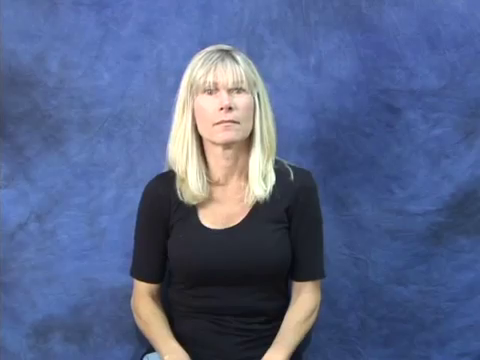

In [22]:
# Example of a gloss mean(221) with multiple meanings
import decord
from IPython.display import display, clear_output
import time
from PIL import Image
vr = decord.VideoReader('/auto/plzen4-ntis/projects/korpusy_cv/WLASL/WLASL300/val/221/67880.mp4') #mean, meaning https://www.handspeak.com/word/1364/

for frame in vr:
    img = Image.fromarray(frame.asnumpy())
    clear_output(wait=True)
    display(img)
    time.sleep(1/vr.get_avg_fps())

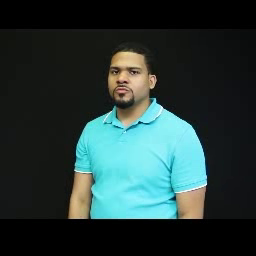

In [31]:
# The same gloss mean(221) with a different meaning
vr = decord.VideoReader('/auto/plzen4-ntis/projects/korpusy_cv/WLASL/WLASL300/val/221/35291.mp4') #mean, unkind https://www.handspeak.com/word/1365/

for frame in vr:
    img = Image.fromarray(frame.asnumpy())
    clear_output(wait=True)
    display(img)
    time.sleep(1/vr.get_avg_fps())